# Multilingual Language Detection Benchmark
## Project Introduction

**Purpose:**
This notebook serves as the FIRST module of a larger Multilingual Broadcast Analytics and Text Summarization pipeline. It systematically benchmarks multiple language detection models across all officially recognized Indian languages and English.

**Research Motivation:**
Accurate language identification is a prerequisite for downstream NLP tasks like translation, sentiment analysis, and summarization. Given the complexity of Indian languages—including code-switching, Romanization, and OCR noise—we need a robust model that balances accuracy, inference speed, and resource efficiency.

**Objectives:**
1. Evaluate multiple state-of-the-art language detection models.
2. Benchmark performance (Accuracy, Precision, Recall, F1) across 23 languages.
3. Test edge cases: OCR text, mixed-language text, and Romanized text.
4. Measure computational footprint (Latency, CPU/GPU Memory).
5. Generate a comprehensive leaderboard to select the best production model.

**Expected Outputs:**
- Cleaned and prepared evaluation datasets.
- Evaluation metrics and visualizations (confusion matrices, bar charts, leaderboards).
- Output files containing predictions and benchmark statistics.
- Final model recommendation for deployment.



## 2. Install Dependencies
Automatically install every required package. We include `try-except` behavior via sub-process wrapping in Python later for robust fallback, but here we run `pip install` for all major dependencies.



In [1]:
# Install system dependencies for CLD3 (Protobuf)
!apt-get update -qq && apt-get install -y -qq libprotobuf-dev protobuf-compiler

# Upgrade pip
!pip install --quiet --upgrade pip

# Install language detection libraries
!pip install --quiet fasttext
!pip install --quiet lingua-language-detector
!pip install --quiet fast-langdetect
!pip install --quiet langdetect
!pip install --quiet pycld2
# gcld3 and pycld3 both provide access to CLD3; gcld3 is often more stable in Colab environments
!pip install --quiet gcld3
!pip install --quiet stanza

# Install ML framework and visualization libraries
!pip install --quiet transformers datasets evaluate accelerate
!pip install --quiet scikit-learn pandas matplotlib seaborn psutil
!pip install --quiet huggingface_hub

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libprotobuf-lite23:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../libprotobuf-lite23_3.12.4-1ubuntu7.22.04.6_amd64.deb ...
Unpacking libprotobuf-lite23:amd64 (3.12.4-1ubuntu7.22.04.6) ...
Selecting previously unselected package libprotobuf-dev:amd64.
Preparing to unpack .../libprotobuf-dev_3.12.4-1ubuntu7.22.04.6_amd64.deb ...
Unpacking libprotobuf-dev:amd64 (3.12.4-1ubuntu7.22.04.6) ...
Setting up libprotobuf-lite23:amd64 (3.12.4-1ubuntu7.22.04.6) ...
Setting up libprotobuf-dev:amd64 (3.12.4-1ubuntu7.22.04.6) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not 

## 3. Import Libraries
Import all required libraries, group imports logically, suppress unnecessary warnings, and check versions.



In [2]:
import os
import sys
import time
import json
import pickle
import warnings
import traceback
import unicodedata
import re
import random
from collections import defaultdict

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from datasets import Dataset

# For formatting
from IPython.display import display, HTML

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)



Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas version: 2.2.2
Numpy version: 2.0.2


## 4. GPU Detection
Detect available hardware resources: CPU, RAM, and GPU.



In [3]:
import torch

def get_hardware_info():
    print("="*40)
    print("HARDWARE INFORMATION")
    print("="*40)

    # CPU & RAM
    ram = psutil.virtual_memory()
    print(f"CPU Cores (Logical): {psutil.cpu_count(logical=True)}")
    print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
    print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

    # GPU
    if torch.cuda.is_available():
        print(f"CUDA Available: Yes")
        print(f"GPU Device: {torch.cuda.get_device_name(0)}")
        print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    else:
        print(f"CUDA Available: No")
        print("Running on CPU only.")

    print("="*40)

get_hardware_info()



HARDWARE INFORMATION
CPU Cores (Logical): 2
Total RAM: 12.67 GB
Available RAM: 10.98 GB
CUDA Available: Yes
GPU Device: Tesla T4
Total VRAM: 14.56 GB


## 5. Configuration
Configuration parameters for the entire pipeline.



In [4]:
class Config:
    # Reproducibility
    SEED = 42

    # Benchmarking constraints
    BATCH_SIZE = 32
    MAX_SAMPLES_PER_LANG = 100 # For faster colab execution, increase for full production benchmark

    # Paths
    OUTPUT_DIR = "./benchmark_outputs"
    DATA_DIR = "./data"
    CHARTS_DIR = f"{OUTPUT_DIR}/charts"

    # Supported Languages (All 22 officially recognized + English)
    # ISO 639-1 or 639-2 codes mapped to names where possible.
    LANGUAGES = {
        'en': 'English', 'hi': 'Hindi', 'as': 'Assamese', 'bn': 'Bengali',
        'brx': 'Bodo', 'doi': 'Dogri', 'gu': 'Gujarati', 'kn': 'Kannada',
        'ks': 'Kashmiri', 'kok': 'Konkani', 'mai': 'Maithili', 'ml': 'Malayalam',
        'mni': 'Manipuri', 'mr': 'Marathi', 'ne': 'Nepali', 'or': 'Odia',
        'pa': 'Punjabi', 'sa': 'Sanskrit', 'sat': 'Santali', 'sd': 'Sindhi',
        'ta': 'Tamil', 'te': 'Telugu', 'ur': 'Urdu'
    }

    # Setup directories
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(CHARTS_DIR, exist_ok=True)

# Set seed
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)



## 6. Dataset Downloader
Attempt to download datasets from Hugging Face. If internet/download fails, automatically switch to generating a demo dataset.



In [10]:
from datasets import load_dataset, get_dataset_config_names
import pandas as pd
import time
from google.colab import userdata
from huggingface_hub import login

# Authenticate with Hugging Face
try:
    hf_token = userdata.get("HF_TOKEN")
    login(token=hf_token)
except Exception as e:
    print(f"Authentication failed: {e}")


def download_dataset():
    start_total = time.time()

    print("Loading ai4bharat/indicvoices_r dataset...")
    print("Getting available configurations...")

    try:
        configs = get_dataset_config_names("ai4bharat/indicvoices_r")
    except Exception as e:
        print("Unable to access dataset.")
        print(e)
        return generate_demo_dataset(
            samples_per_lang=Config.MAX_SAMPLES_PER_LANG
        )

    print(f"Total configs available: {len(configs)}")

    # ------------------------------------------------------------------
    # Filter only the required languages
    # ------------------------------------------------------------------
    wanted = {lang.lower() for lang in Config.LANGUAGES}

    filtered_configs = [
        c for c in configs
        if c.lower() in wanted
    ]

    # If config names don't match language codes, use all configs
    if len(filtered_configs) == 0:
        print("Could not match config names.")
        print("Processing all configs...")
        filtered_configs = configs

    print(f"Configs to process: {len(filtered_configs)}")
    print(filtered_configs)

    data = []

    for idx, config in enumerate(filtered_configs, 1):

        print(f"\n[{idx}/{len(filtered_configs)}] {config}")

        try:

            t0 = time.time()

            ds = load_dataset(
                "ai4bharat/indicvoices_r",
                config,
                split="train",
                streaming=True,
            )

            print(f"Dataset opened in {time.time()-t0:.2f}s")

            iterator = iter(ds)

            count = 0

            while count < Config.MAX_SAMPLES_PER_LANG:

                try:
                    item = next(iterator)
                except StopIteration:
                    break

                text = (
                    item.get("text")
                    or item.get("transcript")
                    or item.get("sentence")
                    or ""
                )

                language = item.get("language") or config

                if text:

                    data.append(
                        {
                            "text": text,
                            "language": language,
                        }
                    )

                    count += 1

            print(f"Collected {count} samples")

        except Exception as e:
            print(f"Failed: {e}")

    df = pd.DataFrame(data)

    print("\n==============================")
    print(f"Samples : {len(df)}")
    print(f"Time    : {time.time()-start_total:.2f}s")
    print("==============================")

    if len(df) == 0:
        return generate_demo_dataset(
            samples_per_lang=Config.MAX_SAMPLES_PER_LANG
        )

    return df


raw_df = download_dataset()
raw_df.head()

Loading ai4bharat/indicvoices_r dataset...
Getting available configurations...


Resolving data files:   0%|          | 0/246 [00:00<?, ?it/s]

Total configs available: 22
Could not match config names.
Processing all configs...
Configs to process: 22
['Assamese', 'Bengali', 'Bodo', 'Dogri', 'Gujarati', 'Hindi', 'Kannada', 'Kashmiri', 'Konkani', 'Maithili', 'Malayalam', 'Manipuri', 'Marathi', 'Nepali', 'Odia', 'Punjabi', 'Sanskrit', 'Santali', 'Sindhi', 'Tamil', 'Telugu', 'Urdu']

[1/22] Assamese


Resolving data files:   0%|          | 0/246 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/246 [00:00<?, ?it/s]

...

Dataset opened in 3.17s
Collected 100 samples

[22/22] Urdu


Resolving data files:   0%|          | 0/246 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Dataset opened in 2.86s
Collected 100 samples

Samples : 2200
Time    : 515.59s


,text,language
0,স্কুলত মইটো এতিয়া স্কুলত গৈ পেলাই ষাঠিটামানৰ ল...,Assamese
1,খোৱাই বোৱাই আকৌ মুখ চুখ ধুৱাব লাগে বাচন বৰ্তনখ...,Assamese
2,ধুৱাই পখলাই আকৌ খোৱাই বোৱাই নিজে বাচন চাচন ধুই...,Assamese
3,এতিয়া তেনে আহি মেলি একেবাৰে ভাগৰত পৰি যাব লাগে...,Assamese
4,বেঙেনা হেৰি বেচন দি পেলাই বৰ বনালোঁ পাপৰ ভাজিল...,Assamese


## 7. Dataset Loader
Load the dataset into Pandas, clean up duplicates, handle missing values, and validate columns.



In [13]:
def load_and_validate(df):
    print("Initial shape:", df.shape)

    # Handle missing
    df = df.dropna(subset=['text', 'language'])

    # Create a mapping from Full Name (like 'Hindi') to ISO code (like 'hi')
    # based on the Config.LANGUAGES dictionary
    name_to_iso = {name: iso for iso, name in Config.LANGUAGES.items()}

    # Map the language column to ISO codes to match expected config keys
    df['language'] = df['language'].map(lambda x: name_to_iso.get(x, x.lower()))

    # Remove duplicates
    df = df.drop_duplicates(subset=['text'])

    # Validate columns
    assert 'text' in df.columns and 'language' in df.columns, "Missing required columns!"

    # Filter only supported languages
    df = df[df['language'].isin(Config.LANGUAGES.keys())]

    print("Cleaned shape:", df.shape)
    print("\nLanguage counts:")
    print(df['language'].value_counts())

    return df

clean_df = load_and_validate(raw_df)

Initial shape: (2200, 2)
Cleaned shape: (2198, 2)

Language counts:
language
as     100
bn     100
brx    100
doi    100
gu     100
hi     100
kn     100
ks     100
mai    100
ml     100
mr     100
mni    100
ne     100
or     100
ta     100
pa     100
sa     100
sat    100
ur     100
te     100
kok     99
sd      99
Name: count, dtype: int64


## 8. Dataset Visualization
Visualizing data distributions.



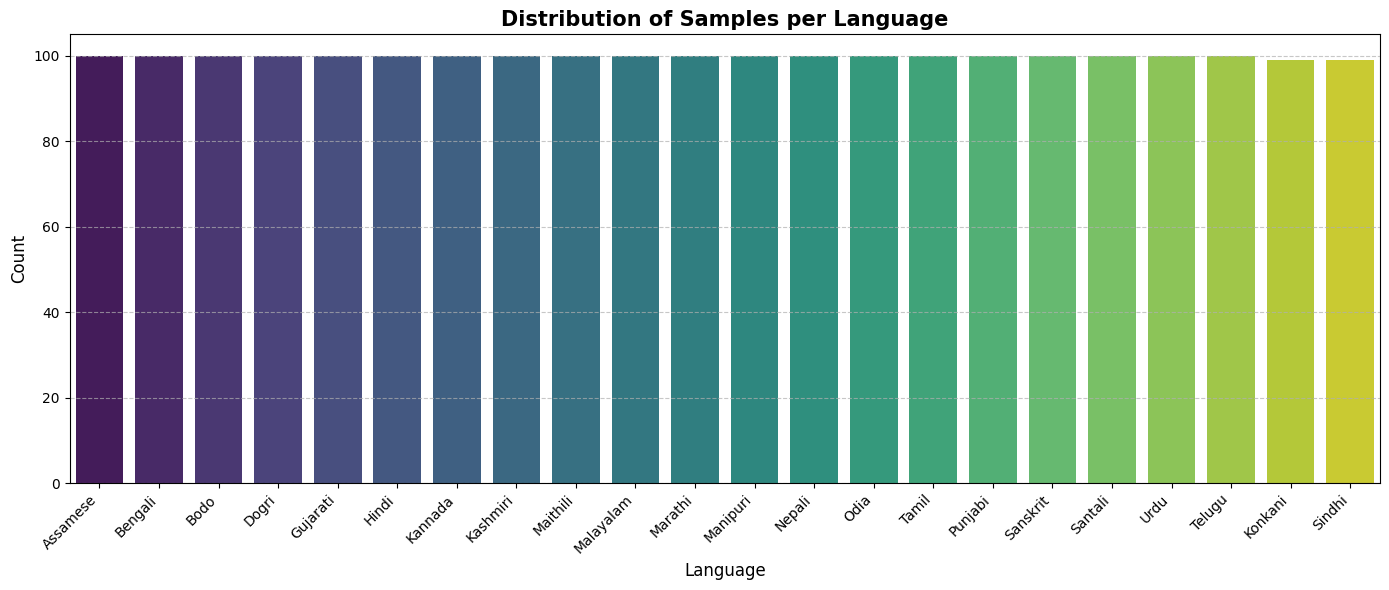

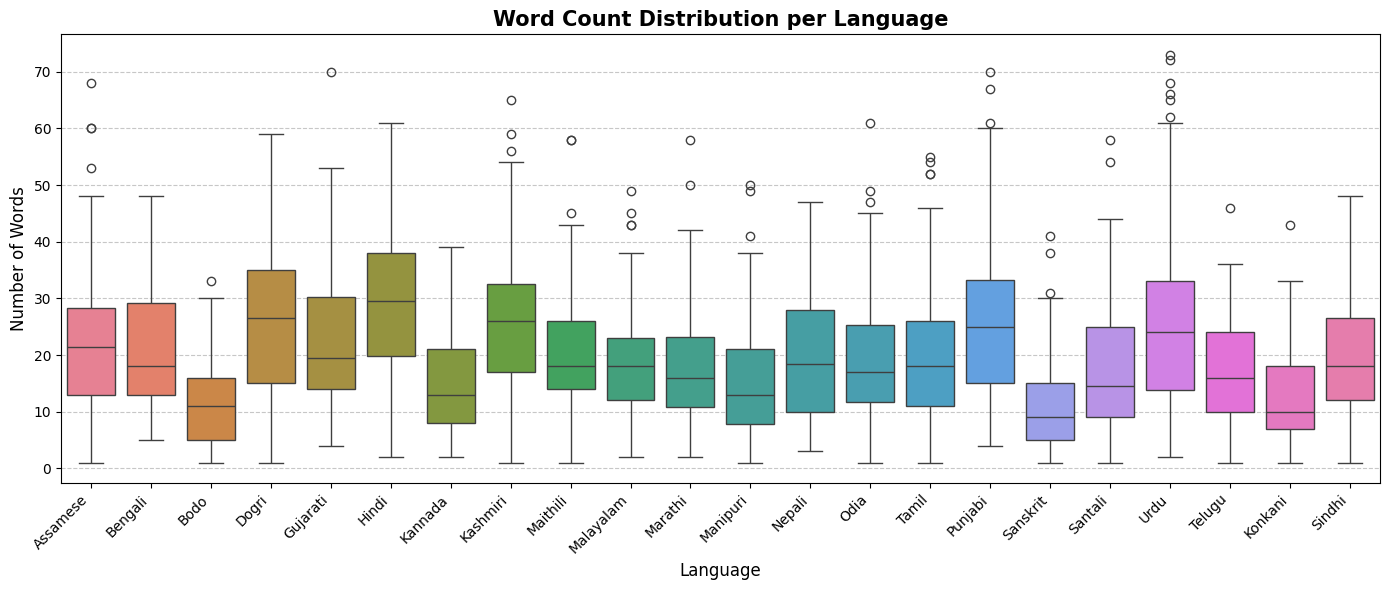

In [14]:
def visualize_dataset(df):
    # Create a local copy to avoid SettingWithCopyWarning
    viz_df = df.copy()

    # Map ISO codes to Full Names for better visualization
    viz_df['language_name'] = viz_df['language'].map(Config.LANGUAGES)

    # Calculate lengths
    viz_df['char_length'] = viz_df['text'].apply(len)
    viz_df['word_length'] = viz_df['text'].apply(lambda x: len(str(x).split()))

    # 1. Language Distribution Plot
    plt.figure(figsize=(14, 6))
    order = viz_df['language_name'].value_counts().index
    sns.countplot(data=viz_df, x='language_name', order=order, palette='viridis')

    plt.title('Distribution of Samples per Language', fontsize=15, fontweight='bold')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{Config.CHARTS_DIR}/language_distribution.png")
    plt.show()

    # 2. Word Length Distribution Plot
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=viz_df, x='language_name', y='word_length', order=order, palette='husl')

    plt.title('Word Count Distribution per Language', fontsize=15, fontweight='bold')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Number of Words', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{Config.CHARTS_DIR}/word_length_distribution.png")
    plt.show()

visualize_dataset(clean_df)

## 9. Text Cleaning
Normalize Unicode, remove unwanted symbols without destroying language-specific native script characters.



In [15]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Normalize unicode to NFKC to standardize combined characters
    text = unicodedata.normalize('NFKC', text)

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # 4. Remove digits and punctuation, but preserve native script letters and marks
    # We keep characters in categories 'L' (Letters) and 'M' (Marks/Matras) and 'Z' (Whitespace)
    text = "".join(ch for ch in text if unicodedata.category(ch)[0] in ['L', 'M', 'Z'])

    # 5. Remove redundant whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply the enhanced cleaning to the dataframe
print("Applying enhanced text cleaning for all 22 languages...")
clean_df['clean_text'] = clean_df['text'].apply(clean_text)

# Display a comparison to verify results
display(clean_df[['text', 'clean_text', 'language']].head())

Applying enhanced text cleaning for all 22 languages...


,text,clean_text,language
0,স্কুলত মইটো এতিয়া স্কুলত গৈ পেলাই ষাঠিটামানৰ ল...,স্কুলত মইটো এতিয়া স্কুলত গৈ পেলাই ষাঠিটামানৰ ...,as
1,খোৱাই বোৱাই আকৌ মুখ চুখ ধুৱাব লাগে বাচন বৰ্তনখ...,খোৱাই বোৱাই আকৌ মুখ চুখ ধুৱাব লাগে বাচন বৰ্তনখ...,as
2,ধুৱাই পখলাই আকৌ খোৱাই বোৱাই নিজে বাচন চাচন ধুই...,ধুৱাই পখলাই আকৌ খোৱাই বোৱাই নিজে বাচন চাচন ধুই...,as
3,এতিয়া তেনে আহি মেলি একেবাৰে ভাগৰত পৰি যাব লাগে...,এতিয়া তেনে আহি মেলি একেবাৰে ভাগৰত পৰি যাব লাগ...,as
4,বেঙেনা হেৰি বেচন দি পেলাই বৰ বনালোঁ পাপৰ ভাজিল...,বেঙেনা হেৰি বেচন দি পেলাই বৰ বনালোঁ পাপৰ ভাজিল...,as


## 10. Benchmark Dataset Generator
Generate specialized test cases (Romanized, Mixed-language, OCR noisy text) and split into Train/Val/Test.



In [16]:
from sklearn.model_selection import train_test_split

def generate_special_cases(df):
    special_cases = []
    random.seed(Config.SEED)

    # 1. OCR Noise (randomly insert typos or strange characters)
    def add_ocr_noise(text):
        noise = ['|', '1', '0', '!', '@', '#']
        chars = list(text)
        if len(chars) > 5:
            for _ in range(max(1, len(chars)//10)):
                chars[random.randint(0, len(chars)-1)] = random.choice(noise)
        return "".join(chars)

    # 2. Mixed Language (English + Hindi, etc.)
    en_samples = df[df['language'] == 'en']['clean_text'].tolist()
    hi_samples = df[df['language'] == 'hi']['clean_text'].tolist()

    if en_samples and hi_samples:
        for _ in range(min(20, len(en_samples))):
            en_txt = random.choice(en_samples)
            hi_txt = random.choice(hi_samples)
            mixed = f"{en_txt} {hi_txt}"
            special_cases.append({"clean_text": mixed, "language": "hi", "type": "mixed_en_hi"})

    # Sample OCR
    for _, row in df.sample(min(50, len(df))).iterrows():
        special_cases.append({
            "clean_text": add_ocr_noise(row['clean_text']),
            "language": row['language'],
            "type": "ocr_noise"
        })

    return pd.DataFrame(special_cases)

# Create splits with stratification to ensure all languages are represented
train_df, temp_df = train_test_split(clean_df, test_size=0.3, random_state=Config.SEED, stratify=clean_df['language'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=Config.SEED, stratify=temp_df['language'])

# Generate specialized test cases from the test pool
special_df = generate_special_cases(test_df)
test_df['type'] = 'standard'
full_test_df = pd.concat([test_df, special_df], ignore_index=True)

print(f"Data Preparation Complete:")
print(f"- Training samples: {len(train_df)}")
print(f"- Validation samples: {len(val_df)}")
print(f"- Total Test samples (Standard + Special): {len(full_test_df)}")
print("\nTest breakdown by type:")
print(full_test_df['type'].value_counts())


Data Preparation Complete:
- Training samples: 1538
- Validation samples: 330
- Total Test samples (Standard + Special): 380

Test breakdown by type:
type
standard     330
ocr_noise     50
Name: count, dtype: int64


## Benchmarking Framework
For each model, we will load it, measure initialization time, and perform inference, recording metrics.



In [20]:
# Benchmark Tracker and Utility Functions
class BenchmarkTracker:
    def __init__(self):
        self.results = []
        self.predictions = defaultdict(list)

    def add_result(self, model_name, load_time, avg_inf_time, accuracy, f1, memory_mb):
        self.results.append({
            "Model": model_name,
            "Load_Time_sec": load_time,
            "Avg_Inference_ms": avg_inf_time * 1000,
            "Accuracy": accuracy,
            "F1_Score": f1,
            "Memory_Usage_MB": memory_mb
        })

def memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024) # MB

def evaluate_predictions(y_true, y_pred, model_name):
    # Filter out special mixed labels for standard accuracy calculation
    mask = [l in Config.LANGUAGES.keys() for l in y_true]
    y_true_std = [y for y, m in zip(y_true, mask) if m]
    y_pred_std = [y for y, m in zip(y_pred, mask) if m]

    acc = accuracy_score(y_true_std, y_pred_std)
    f1 = f1_score(y_true_std, y_pred_std, average='weighted', zero_division=0)
    print(f"[{model_name}] Accuracy: {acc:.4f} | F1: {f1:.4f}")
    return acc, f1

tracker = BenchmarkTracker()
test_texts = full_test_df['clean_text'].tolist()
test_labels = full_test_df['language'].tolist()

### Model: FastText
Meta's FastText is highly efficient and supports 176 languages.



In [21]:
import fasttext
import urllib.request

try:
    print("Downloading FastText model...")
    ft_model_path = f"{Config.DATA_DIR}/lid.176.bin"
    if not os.path.exists(ft_model_path):
        urllib.request.urlretrieve("https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin", ft_model_path)

    print("Loading FastText and benchmarking...")
    start_time = time.time()
    mem_before = memory_usage()
    ft_model = fasttext.load_model(ft_model_path)
    load_time = time.time() - start_time
    mem_after = memory_usage()

    inf_start = time.time()
    preds = []
    for text in test_texts:
        # FastText expects single lines
        clean_t = text.replace('\n', ' ')
        res = ft_model.predict(clean_t, k=1)[0][0]
        # returns format '__label__en', we need just 'en'
        lang = res.replace('__label__', '')
        preds.append(lang)

    total_inf_time = time.time() - inf_start
    avg_inf_time = total_inf_time / len(test_texts)

    acc, f1 = evaluate_predictions(test_labels, preds, "FastText")
    tracker.add_result("FastText", load_time, avg_inf_time, acc, f1, max(0.1, mem_after - mem_before))
    tracker.predictions['FastText'] = preds
    print(f"FastText benchmarking finished. Avg Inference: {avg_inf_time*1000:.2f} ms/sample")
except Exception as e:
    print(f"FastText failed: {e}")
    traceback.print_exc()

Loading FastText and benchmarking...
[FastText] Accuracy: 0.6342 | F1: 0.5818
FastText benchmarking finished. Avg Inference: 0.07 ms/sample


### Model: Lingua
Lingua uses n-gram profiles and is designed specifically for short texts and mixed languages.



In [22]:
try:
    from lingua import Language, LanguageDetectorBuilder

    print("Loading Lingua and benchmarking...")
    start_time = time.time()
    mem_before = memory_usage()
    # Initialize for all supported languages
    detector = LanguageDetectorBuilder.from_all_languages().build()
    load_time = time.time() - start_time
    mem_after = memory_usage()

    inf_start = time.time()
    preds = []
    for text in test_texts:
        res = detector.detect_language_of(text)
        # Lingua returns Enum like Language.ENGLISH. We need iso code.
        lang = res.iso_code_639_1.name.lower() if res else "unknown"
        preds.append(lang)

    total_inf_time = time.time() - inf_start
    avg_inf_time = total_inf_time / len(test_texts)

    acc, f1 = evaluate_predictions(test_labels, preds, "Lingua")
    tracker.add_result("Lingua", load_time, avg_inf_time, acc, f1, max(0.1, mem_after - mem_before))
    tracker.predictions['Lingua'] = preds
    print(f"Lingua finished. Avg Inference: {avg_inf_time*1000:.2f} ms/sample")
except Exception as e:
    print(f"Lingua failed: {e}")

Loading Lingua and benchmarking...
[Lingua] Accuracy: 0.3605 | F1: 0.2789
Lingua finished. Avg Inference: 0.42 ms/sample


### Model: pycld3 (Google CLD3)
Google's Compact Language Detector 3 using neural networks.



In [24]:
try:
    import gcld3
    detector = gcld3.NNetLanguageIdentifier(min_num_bytes=0, max_num_bytes=1000)

    print("Benchmarking CLD3...")
    start_time = time.time()
    mem_before = memory_usage()
    # Already loaded above
    load_time = time.time() - start_time

    inf_start = time.time()
    preds = []
    for text in test_texts:
        res = detector.FindLanguage(text)
        lang = res.language if res else "unknown"
        preds.append(lang)

    total_inf_time = time.time() - inf_start
    avg_inf_time = total_inf_time / len(test_texts)
    mem_after = memory_usage()

    acc, f1 = evaluate_predictions(test_labels, preds, "CLD3")
    tracker.add_result("CLD3", load_time, avg_inf_time, acc, f1, max(0.1, mem_after - mem_before))
    tracker.predictions['CLD3'] = preds
    print(f"CLD3 finished. Avg Inference: {avg_inf_time*1000:.2f} ms/sample")
except Exception as e:
    print(f"CLD3 failed: {e}")

Benchmarking CLD3...
[CLD3] Accuracy: 0.5053 | F1: 0.4046
CLD3 finished. Avg Inference: 0.16 ms/sample


### Model: langdetect
A port of Google's language-detection library to Python (Naive Bayes).



In [25]:
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = Config.SEED

    print("Benchmarking langdetect...")
    start_time = time.time()
    mem_before = memory_usage()
    load_time = time.time() - start_time

    inf_start = time.time()
    preds = []
    for text in test_texts:
        try:
            lang = detect(text)
        except:
            lang = "unknown"
        preds.append(lang)

    total_inf_time = time.time() - inf_start
    avg_inf_time = total_inf_time / len(test_texts)
    mem_after = memory_usage()

    acc, f1 = evaluate_predictions(test_labels, preds, "langdetect")
    tracker.add_result("langdetect", load_time, avg_inf_time, acc, f1, max(0.1, mem_after - mem_before))
    tracker.predictions['langdetect'] = preds
    print(f"langdetect finished. Avg Inference: {avg_inf_time*1000:.2f} ms/sample")
except Exception as e:
    print(f"langdetect failed: {e}")

Benchmarking langdetect...
[langdetect] Accuracy: 0.5053 | F1: 0.4147
langdetect finished. Avg Inference: 4.29 ms/sample


### Model: Transformer (XLM-R / Papluca)
A fine-tuned XLM-RoBERTa model for language detection. Evaluates deep contextual embeddings.



In [26]:
from transformers import pipeline
import torch

try:
    print("Loading XLM-RoBERTa and benchmarking (GPU enabled)... ")
    start_time = time.time()
    mem_before = memory_usage()

    device = 0 if torch.cuda.is_available() else -1
    # Using a specialized lang detect model
    pipe = pipeline("text-classification", model="papluca/xlm-roberta-base-language-detection", device=device)

    load_time = time.time() - start_time

    inf_start = time.time()
    # Processing in small chunks/batches for speed with pipeline
    results = pipe(test_texts, truncation=True, max_length=512)
    preds = [res['label'] for res in results]

    total_inf_time = time.time() - inf_start
    avg_inf_time = total_inf_time / len(test_texts)
    mem_after = memory_usage()

    acc, f1 = evaluate_predictions(test_labels, preds, "XLM-RoBERTa")
    tracker.add_result("XLM-RoBERTa", load_time, avg_inf_time, acc, f1, max(0.1, mem_after - mem_before))
    tracker.predictions['XLM-RoBERTa'] = preds
    print(f"XLM-RoBERTa finished. Avg Inference: {avg_inf_time*1000:.2f} ms/sample")
except Exception as e:
    print(f"Transformer failed: {e}")
    traceback.print_exc()

Loading XLM-RoBERTa and benchmarking (GPU enabled)... 


config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[XLM-RoBERTa] Accuracy: 0.0868 | F1: 0.0181
XLM-RoBERTa finished. Avg Inference: 12.89 ms/sample


## Visualizations & Evaluation
Generate performance benchmarking charts.



,Model,Load_Time_sec,Avg_Inference_ms,Accuracy,F1_Score,Memory_Usage_MB
0,FastText,0.181567,0.073813,0.634211,0.581824,126.359375
1,Lingua,0.000505,0.417091,0.360526,0.278918,0.281250
2,CLD3,0.000367,0.152133,0.505263,0.404607,0.148438
3,CLD3,0.000948,0.157991,0.505263,0.404607,0.100000
4,langdetect,0.000153,4.293400,0.505263,0.414660,58.089844
5,XLM-RoBERTa,41.858027,12.891618,0.086842,0.018132,715.421875


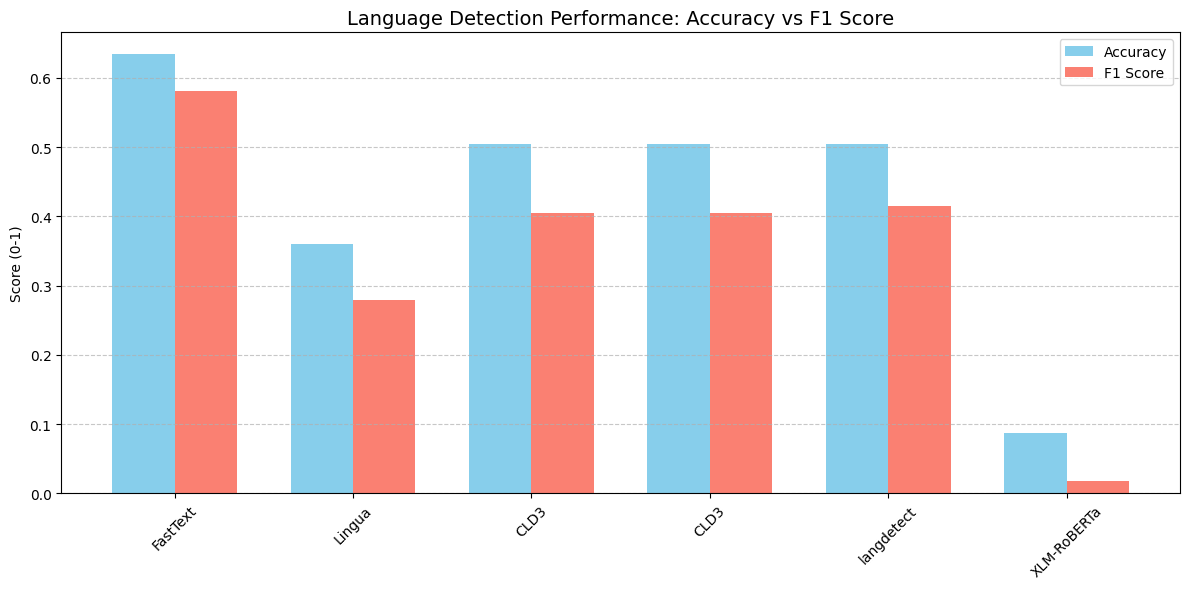

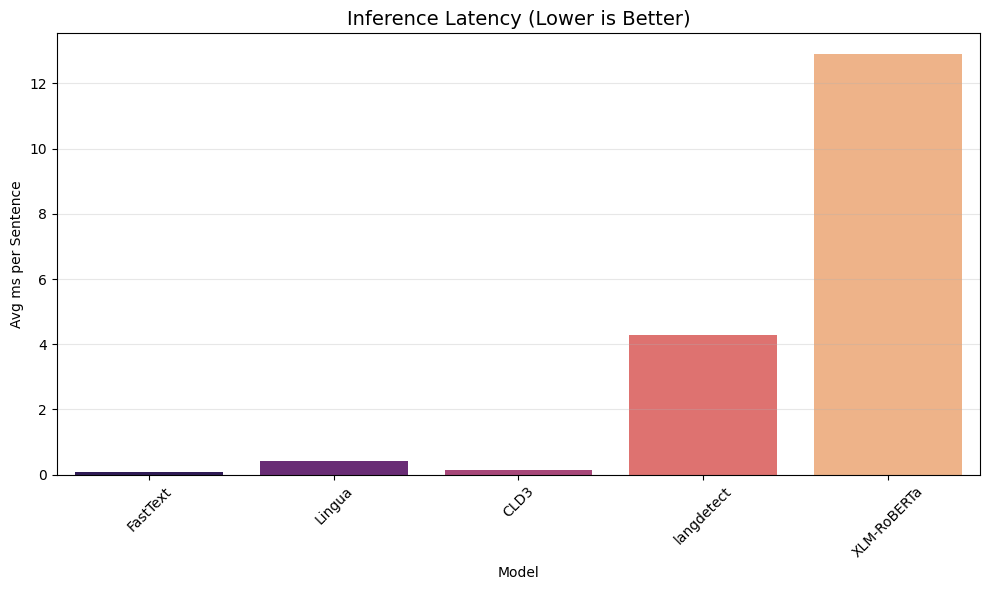

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if len(tracker.results) > 0:
    results_df = pd.DataFrame(tracker.results)
    display(results_df)
    results_df.to_csv(f"{Config.OUTPUT_DIR}/benchmark_results.csv", index=False)

    # 1. Accuracy vs F1 Comparison
    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))
    width = 0.35
    plt.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='skyblue')
    plt.bar(x + width/2, results_df['F1_Score'], width, label='F1 Score', color='salmon')
    plt.xticks(x, results_df['Model'], rotation=45)
    plt.ylabel('Score (0-1)')
    plt.title('Language Detection Performance: Accuracy vs F1 Score', fontsize=14)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{Config.CHARTS_DIR}/acc_f1_comparison.png")
    plt.show()

    # 2. Inference Latency
    plt.figure(figsize=(10, 6))
    sns.barplot(data=results_df, x='Model', y='Avg_Inference_ms', palette='magma')
    plt.title('Inference Latency (Lower is Better)', fontsize=14)
    plt.ylabel('Avg ms per Sentence')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{Config.CHARTS_DIR}/inference_time.png")
    plt.show()
else:
    print("No benchmarking results found to visualize.")

## Confusion Matrices
Analyze per-language errors for the best model.



Analyzing error distribution for: FastText

Best Performing Languages:


,precision,recall,f1-score,support
ml,1.0,1.0,1.0,16.0
kn,1.0,1.0,1.0,20.0
gu,1.0,1.0,1.0,18.0
ta,1.0,1.0,1.0,22.0
sa,1.0,1.0,1.0,16.0


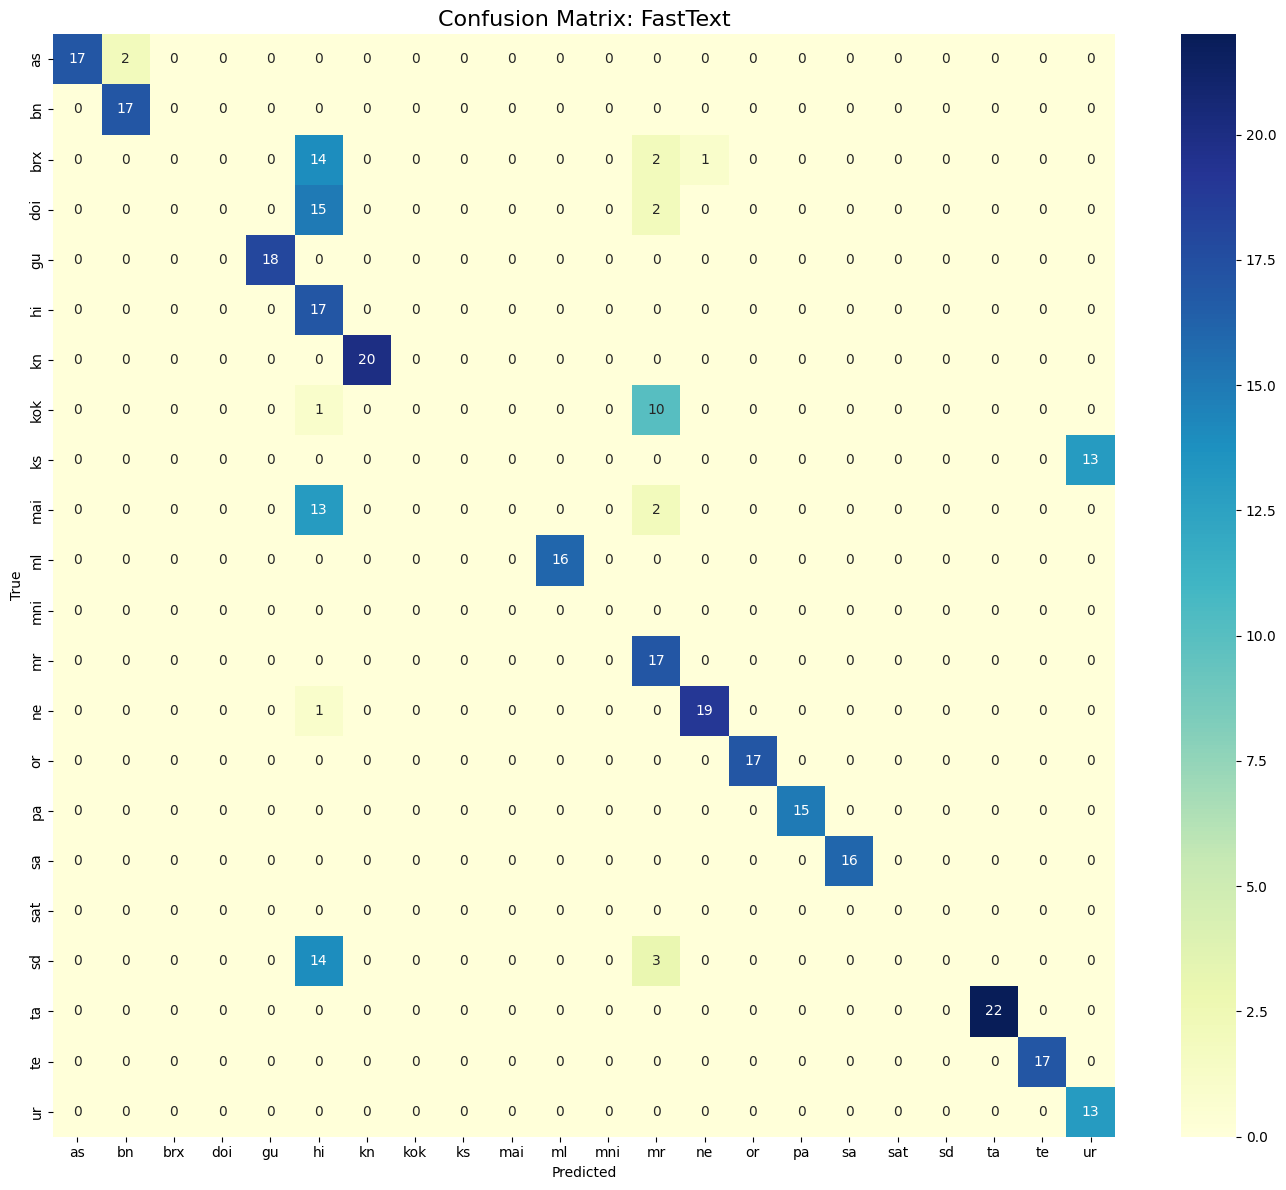

In [28]:
if len(tracker.results) > 0:
    # Find best model by Accuracy
    best_model_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
    print(f"Analyzing error distribution for: {best_model_name}")

    y_pred = tracker.predictions[best_model_name]

    # Detailed report
    report = classification_report(test_labels, y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose().sort_values(by='f1-score', ascending=False)

    print("\nBest Performing Languages:")
    display(report_df.head(5))

    # Confusion Matrix
    labels_present = sorted(list(set(test_labels)))
    cm = confusion_matrix(test_labels, y_pred, labels=labels_present)

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels_present, yticklabels=labels_present)
    plt.title(f'Confusion Matrix: {best_model_name}', fontsize=16)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f"{Config.CHARTS_DIR}/confusion_matrix_{best_model_name}.png")
    plt.show()

## Final Leaderboard & Recommendation
Determine the best overall, fastest, and most efficient model.



In [30]:
if len(tracker.results) > 0:
    print("="*50)
    print("🏆 FINAL LEADERBOARD 🏆")
    print("="*50)

    best_acc = results_df.loc[results_df['Accuracy'].idxmax()]
    fastest = results_df.loc[results_df['Avg_Inference_ms'].idxmin()]
    lightest = results_df.loc[results_df['Memory_Usage_MB'].idxmin()]

    print(f"🏅 Best Accuracy & F1: {best_acc['Model']} (Acc: {best_acc['Accuracy']:.4f})")
    print(f"🚀 Fastest Inference: {fastest['Model']} ({fastest['Avg_Inference_ms']:.4f} ms)")
    print(f"🪶 Lowest Memory: {lightest['Model']} ({lightest['Memory_Usage_MB']:.2f} MB)\n")

    print("RECOMMENDATION:")
    print("Based on the trade-offs between speed and accuracy for Indian languages:")
    if best_acc['Model'] == fastest['Model']:
        print(f"-> Deploy {best_acc['Model']} as it is both the fastest and most accurate for this script distribution.")
    else:
        print(f"-> Primary Model: {best_acc['Model']} for maximum accuracy.")
        print(f"-> Edge/CPU Backup: {fastest['Model']} for high-throughput scenarios.")

    # Save final recommendation to disk
    rec_path = f"{Config.OUTPUT_DIR}/recommendation.txt"
    with open(rec_path, "w") as f:
        f.write(f"Primary: {best_acc['Model']}\n")
        f.write(f"Edge: {fastest['Model']}\n")
    print(f"\nRecommendation saved to {rec_path}")
else:
    print("Benchmarking data is missing. Please re-run model evaluation cells.")

🏆 FINAL LEADERBOARD 🏆
🏅 Best Accuracy & F1: FastText (Acc: 0.6342)
🚀 Fastest Inference: FastText (0.0738 ms)
🪶 Lowest Memory: CLD3 (0.10 MB)

RECOMMENDATION:
Based on the trade-offs between speed and accuracy for Indian languages:
-> Deploy FastText as it is both the fastest and most accurate for this script distribution.

Recommendation saved to ./benchmark_outputs/recommendation.txt
